# Assignment 03

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
%matplotlib ipympl
%load_ext autoreload
%autoreload 2

## Q1: potential (irrotational) flow

Download the code in `2d-fluid-simulator.zip` and decompress in your working folder.  This simulator will allow you to make 2-D simulations analagous to flow in a wind tunnel or channel, and place obstacles in the channel and observe the flow around them. 

You will need to install `taichi` in a python environment.  I found `taichi` was a little finicky on my system, and had the best result making a new environment:

```
mamba create -n taichi
mamba activate taichi
mamba install python=3.11
pip install taichi
mamba install xarray netcdf4 pillow
```

### Q1.1a run

Run the simulation that has two obstacles at the bottom of a channel:

```
python main.py -bc 11 -re 4_000_000 -res 400 -dt 0.0002 -vc 0.0 \
   --save 1000 --cpu --savedir output2circRe4e6
```
This should display a plot on your screen that updates regularly.  There will also be netcdf files stored in a directory `output2circRe4e6`.  You can stop the simulation after it appears to come to a quasi-steady state (I did about 30k timesteps)

The first circle is centered at $(2/3, 0)$ with a radius of $1/6$.  The second circle is centered at $(8/7, 0)$ with a radius of $1/9$

Run a second time, but change the Reynolds number to 400 instead.

Note these simulations take a while to come to steady state because of the start-up transients in the forcing making waves that slosh back and forth.


### Q1.1b plot:

I could _not_ get taichi to play well with `dask` in xarray, so I analyze the data in a Phy426 environment (`mamba activate Phy426`) and I made sure that environment has dask installed (`mamba install dask`).  



Plot a snapshot near the end of these solutions, preferably at the same simulation time, and compare and contrast the different features.
  
_Hint_: `xr.open_mfdataset('2d-fluid-simulator/output2circRe4e6/output*.nc')` will "open" all the files you created in that subdirectory.  You can then index by time slice (`ds = ds.isel(time=20)`) to get one time slice to plot.  

_Hint_: I plotted the `u` velocity and used the `streamplot` function to plot approximations of the streamlines.

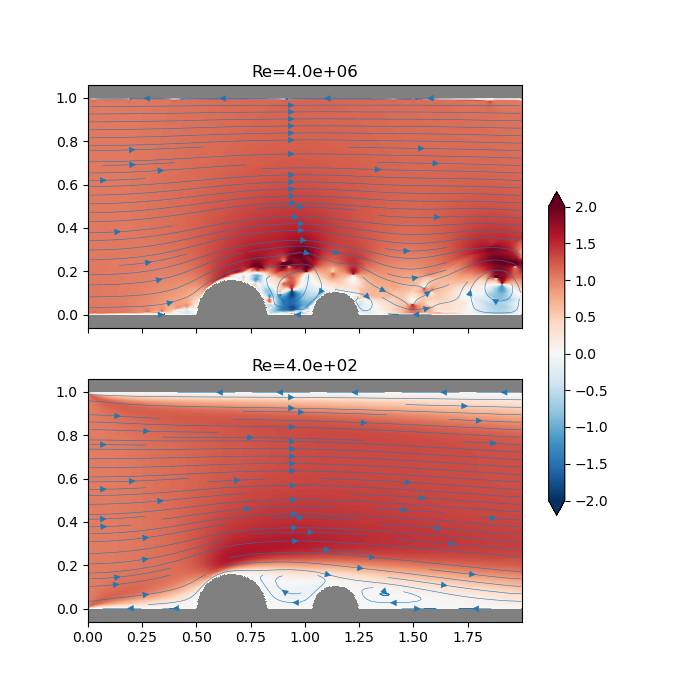

In [238]:
todo = ['2d-fluid-simulator/output2circRe4e6/output*.nc', '2d-fluid-simulator/output2circRe4e2/output*.nc']

fig, axs = plt.subplots(2, 1, sharex=True, sharey=True,
                       figsize=(7, 7))

re = [4e6, 400]
for nn in range(2):
    ax = axs[nn]
    with xr.open_mfdataset(todo[nn]) as ds:
        ds = ds.isel(time=30)
        X, Y = np.meshgrid(ds.x, ds.y)
        ax.streamplot(X, Y, ds.u.T, ds.v.T, linewidth=0.4)
        pc = ax.pcolormesh(ds.x, ds.y, ds.u.T, cmap='RdBu_r', clim=(-2, 2))
        ax.set_title(f'Re={re[nn]:.1e}')
        ax.set_facecolor('0.5')
        ax.set_aspect(1)
fig.colorbar(pc, ax=axs, shrink=0.6, extend='both')

For the higher Reynolds number case, the flow between the two obstacles is quite turbulent, with eddies shedding occasionally and moving downstream.  Far from the obstacles, the flow is relatively constant, though if you watch the animations, you can see instabilities develop along the top wall.

For the lower Reynolds number, thick boundary layers develop on both the top and bottom boundary.   There is a back eddy behind each of the obstacles, though there is little evidence of these shedding downstream.

## Q1.2 Theoretical irrotational; flow

Using a combination of source-sink dipoles and a steady flow, plot the streamlines for a steady irrotational flow around the obstacles used above, and discuss the differences and similarities with the full simulations. 

_Hint_: ignore the upper boundary, and just plot the upper half of the complex plane.  

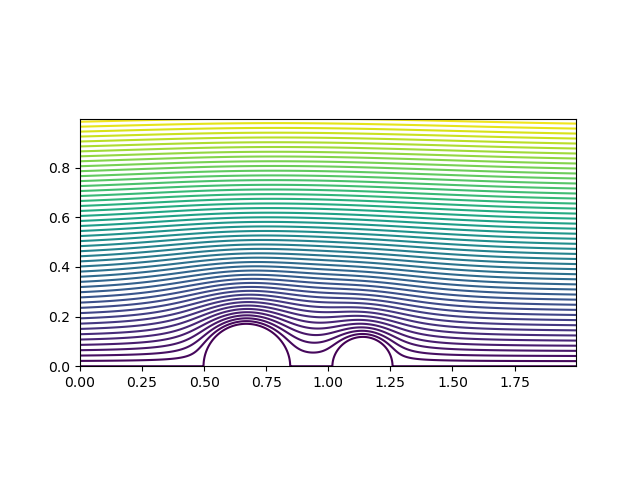

In [239]:
x = ds.x
y = ds.y
X, Y = np.meshgrid(x, y)
zz = X+1j*Y

x1 = 2/3
y1 = 0
r1 = 1/6
x2 = 8/7
y2 = 0
r2 = 1/9
comp = zz+r1**2/(zz-(x1+1j*y1))+r2**2/(zz-(x2+1j*y2))
fig, ax = plt.subplots()
ax.contour(x, y, np.imag(comp-comp[0,0]),np.arange(0.,1.,0.02) )
ax.set_aspect(1)

The response here follows the obstacles much more closely than either of the full Navier-Stokes simulations.  This is perhaps most clearly seen in the lee of the second obstacle, where in both the simulations there is a large back eddy that is not predicted in the ideal simulation.  

Note that the response at the top end is not quite parallel to the edge of the domain, so that adds a bit of extra contraint to the problem.

## Q1.3 numerical approximation to irrotational flow

Use a relaxation method to numerically solve Laplace's equation in the model domain (use the same model domain as the simulation).  Plot, and compare and contrast to both the simulation results and the analytical theory above.

In [ ]:
in1 = np.sqrt((X-x1)**2+(Y-y1)**2)<=r1
in2 = np.sqrt((X-x2)**2+(Y-y2)**2)<=r2
psinew = 0 * X
psinew = np.linspace(0, 1, len(psinew[:, 0]))[:, np.newaxis] + 0 * X
print(np.shape(psinew))
#psinew[0, :] = 0
#psinew[-1, :] = 1

psiold = 1e6*psinew
for nn,tol in enumerate([1.e-6,]):
    maxdiff=1.
    # initialize to be a free stream
    num=0
    while (maxdiff>tol):
        num+=1
        # set psi in the body to a value at the boundary of the body.
        psinew[in1]=0.
        psinew[in2]=0.
        # do the integration:
        psinew[1:-1,1:-1]=0.25*(psinew[0:-2,1:-1]+psinew[2:,1:-1]+ psinew[1:-1,0:-2,]+psinew[1:-1,2:])
        maxdiff = np.max(np.abs(psinew-psiold))
        psiold=psinew.copy()

(400, 800)


[Text(0, 0.5, 'y'), Text(0.5, 1.0, 'numerical approximation')]

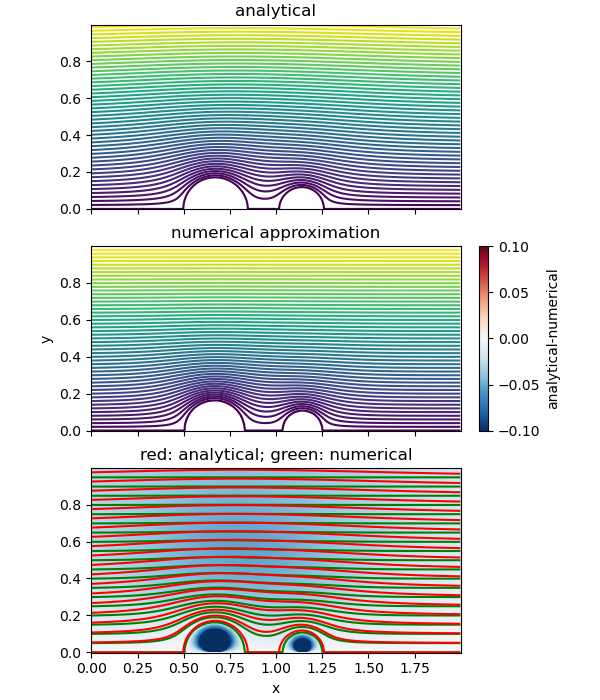

In [242]:
fig, axs = plt.subplots(3, 1, figsize=(6, 7), sharex=True, sharey=True, layout='compressed')
axs[0].contour(x, y, np.imag(comp-comp[0,0]), np.arange(0, 1, 0.02))
axs[0].set(title='analytical')
axs[1].contour(x, y, psinew, np.arange(0, 1, 0.02))
#ax.contour(x, y, np.imag(comp-comp[0,0]),np.arange(0.,1.,0.02) )
axs[1].set_aspect(1)
axs[2].contour(x, y, psinew, np.arange(0, 1, 0.05), colors='g')
axs[2].contour(x, y, np.imag(comp-comp[0,0]), np.arange(0, 1, 0.05), colors='r')
pc = axs[2].pcolormesh(x, y, np.imag(comp-comp[0,0])-psinew, cmap='RdBu_r', clim=(-0.1, 0.1) )
fig.colorbar(pc, ax=axs[1], label='analytical-numerical')
axs[2].set_aspect(1)
axs[2].set(xlabel='x', title='red: analytical; green: numerical')
axs[1].set(ylabel='y', title='numerical approximation')


The analytical and numerical approximations are quite close to one another, with the analytical solution not following the upper boundary exactly there are som edefinite differences to the channel model.  To fix this we could have made the channel wider (or the obstacles smaller).

## Q2: Boundary layer growth

Finite viscosity leads to boundary layers. Make a new solution (this one only needs to run for 10_000 steps or so) using boundary condition 12.

```
python main.py -bc 12 -re 2_000 -res 400 -dt 0.0002 -vc 0.0 \
   --save 1000 --cpu --savedir outputjustwalls
```

This solution is simply flow in a channel with walls at the top and bottom boundaries.  

### Q2.1 plot the boundary layer

Focusing on the top face of the channel, make some images of the flow, and perhaps take an average of a few time steps for the low Reynolds number case (why average?), and describe.

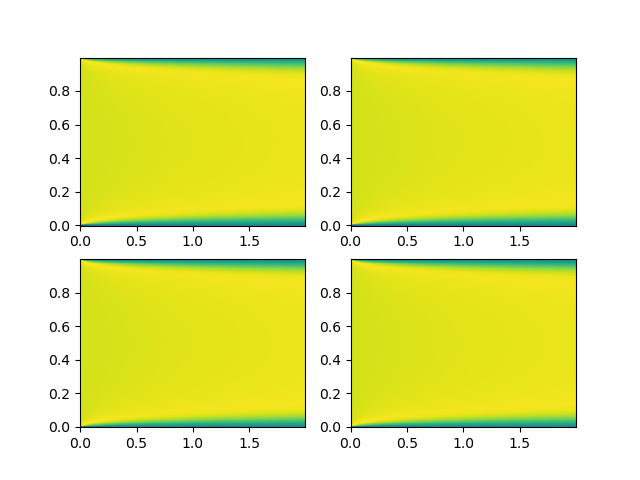

In [244]:
with xr.open_mfdataset('2d-fluid-simulator/outputjustwalls/output*.nc') as ds:
    ds = ds.isel(time=slice(-3,None))
    fig, axs = plt.subplots(2, 2)
    for nn, ax in enumerate(axs.flat):
        if nn < 3:
            ax.pcolormesh(ds.x, ds.y, ds.isel(time=nn).u.T)
        else:
            ax.pcolormesh(ds.x, ds.y, ds.mean(dim='time').u.T)



This shows the last 4 time steps.  We can see the flow is largely in steady state.  The boundary layer grows as the flow develops downstream.  

### Q2.2 Check if upper boundary layer is "self similar"

Check if the numerics indicate that the upper boundary layer is "self-similar" by plotting the vertical profile of along-channel velocity and scaling the vertical axes appropriately by the distance along the channel $x$.  Focus your plots near the bottom of the channel - obviously the upper boundary is fixed in space and doesn't scale with the self similar scaling.

You will need a viscosity for this.  The model is run with L=1 m, and U=1 m/s, so the Reynold's number determines the viscosity. 

<>:14: SyntaxWarning: invalid escape sequence '\d'
<>:14: SyntaxWarning: invalid escape sequence '\d'
/var/folders/kx/4c3bx_w92t31pqyvg6ws03200000gn/T/ipykernel_94367/892449802.py:14: SyntaxWarning: invalid escape sequence '\d'
  axs[1].set(xlabel='U / U_0', ylabel='$y / \delta$',
/var/folders/kx/4c3bx_w92t31pqyvg6ws03200000gn/T/ipykernel_94367/892449802.py:11: RuntimeWarning: divide by zero encountered in divide
  yy = Y / delta
/var/folders/kx/4c3bx_w92t31pqyvg6ws03200000gn/T/ipykernel_94367/892449802.py:11: RuntimeWarning: invalid value encountered in divide
  yy = Y / delta


[Text(0.5, 0, 'U / U_0'),
 Text(0, 0.5, '$y / \\delta$'),
 Text(0.5, 1.0, 'Vertical scaled by $\\delta=\\left(\\nu x / U_0\\right)^{1/2}$')]

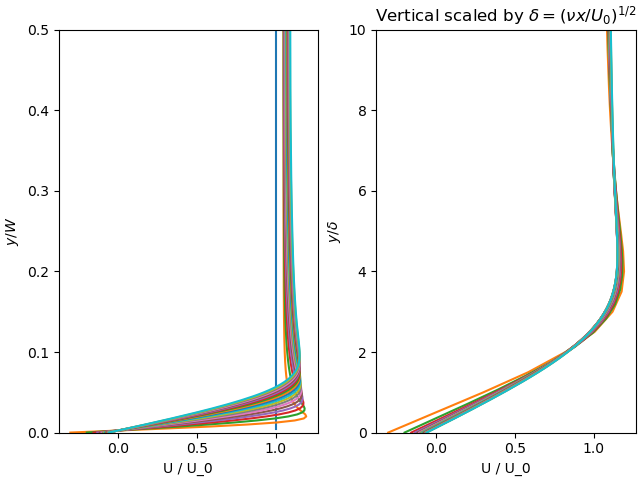

In [245]:
fig, axs = plt.subplots(1, 2, layout='constrained')
axs[0].plot(ds.mean(dim='time').u[:400:20, :].T, ds.y)
axs[0].set_ylim(0., 0.5)
axs[0].set(xlabel='U / U_0', ylabel='$y / W$')
Y, X = np.meshgrid(ds.y, ds.x)
Re = ds.attrs['Re']
U = 1
L = 1
nu = U * L / Re
delta = np.sqrt(nu * X / U)
yy = Y / delta
axs[1].plot(ds.mean(dim='time').u[:400:20, :].T, yy[:400:20, :].T);
axs[1].set_ylim(0., 10)
axs[1].set(xlabel='U / U_0', ylabel='$y / \delta$',
           title=r'Vertical scaled by $\delta=\left(\nu x / U_0\right)^{1/2}$')

So, scaling in the vertical by $x^{1/2}$ is quite effective at making the boundary layer collapse to a self-similar scaling.  Note that this setup is not exactly like the theoretical, in particular there is an upper wall.  The numerical scheme also makes negative velocities, which would not exist in a real boundary layer.  


### Q2.3 Implement a shooting method to calculate the velocity in boundary layer

Using the shooting method to solve the Blasius solution as discussed in the text, and compare and contrast with the simulation above

In [246]:
eta = np.arange(0,20,0.02)
deta = np.median(np.diff(eta))

g = 0.*eta
f = 0.*eta
h = 0.*eta
h_1=[]
g_N=[]

#Integrate once:
h[0]=1.0
for i in range(1,len(eta)):
    f[i]=f[i-1]+g[i-1]*deta
    g[i]=g[i-1]+h[i-1]*deta
    h[i]=h[i-1]-0.5*f[i-1]*h[i-1]*deta
g1 = g[-1]
h1 = h[0]
g_N+=[g1]
h_1+=[h1]

# integrate a second time
g = 0.*eta
f = 0.*eta
h = 0.*eta
h[0]=2.
print(g1)
for i in range(1,len(eta)):
    f[i]=f[i-1]+g[i-1]*deta
    g[i]=g[i-1]+h[i-1]*deta
    h[i]=h[i-1]-0.5*f[i-1]*h[i-1]*deta
g2 = g[-1]
h2 = h[0]
g_N+=[g2]
h_1+=[h2]
print (g1, g2)

# now iterate on two solutions using Newton-Raphson
while (np.abs(g2-1.))>0.001:
    if np.abs(g2-g1)>1e-10:
        h[0]=h[0] - (g1-1.)*(h2-h1)/(g2-g1)
    else: # this shouldn't happen, but if it does, then jump somewhere else and try again...
        h[0]=h[0]+0.1
    if h[0]<0:
        h[0]=0.001
    g1 = g2
    h1 = h2
    g = 0.*eta
    f = 0.*eta
    h[1:]=0.
    for i in range(1,len(eta)):
        f[i]=f[i-1]+g[i-1]*deta
        g[i]=g[i-1]+h[i-1]*deta
        h[i]=h[i-1]-0.5*f[i-1]*h[i-1]*deta
    g2 = g[-1]
    g_N+=[g2]
    h2 = h[0]
    h_1+=[h2]
    #print(g2)

print(h2)
print(g2)

2.1067762924218214
2.1067762924218214 3.3531759839783906
0.328484420054851
0.9998205717574503


0.328484420054851
0.9998205717574503


<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
/var/folders/kx/4c3bx_w92t31pqyvg6ws03200000gn/T/ipykernel_94367/2430562046.py:6: SyntaxWarning: invalid escape sequence '\d'
  ax.set(xlabel='U / U_0', ylabel='$y / \delta$',


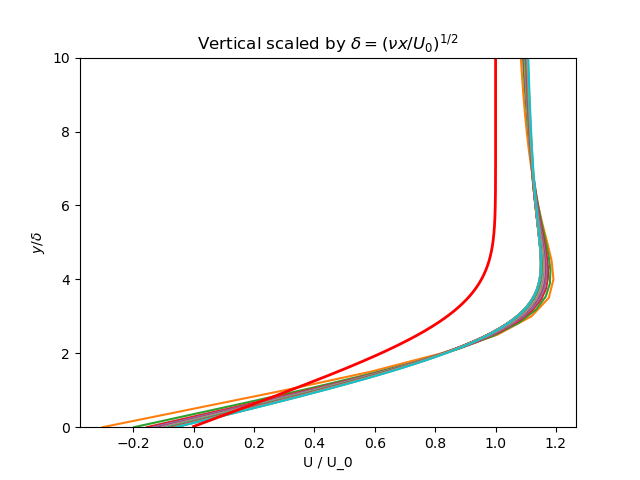

In [247]:
print( h2)
print(g2)
fig,ax=plt.subplots()
ax.plot(ds.mean(dim='time').u[:400:20, :].T, yy[:400:20, :].T);
ax.set_ylim(0., 10)
ax.set(xlabel='U / U_0', ylabel='$y / \delta$',
           title=r'Vertical scaled by $\delta=\left(\nu x / U_0\right)^{1/2}$')
ax.plot(np.diff(f)/ np.diff(f)[-1],eta[1:], lw=2, color='r', label='Theory')

So we see that the theory is close to correct, but that the free-stream flow is faster than expected, and it has a bit more structure right at the top of the boundary layer than predicted by "theory".  This is certainly because the flow is being accelerated along the channel as it contracts, whereas the theory is assuming no boundary at infinity. We could probably resolve with the proper boundary conditions, but we won't do that here.  

## Q3 Airfoils

### Q3.1 make an airfoil shape

`2d-fluid-simulator` allows a boundary condition that uses a shape (any shape!) defined by a black and white image.  

We define an image that makes an airfoil in the image below and save it with a long name.  If we copy that saved png into `2d-fluid-simulator/images/bc_mask/` as "airfoil.png", then we can run the simulation.

We will want some units for the data here.  $U=1\ \mathrm{m\,s^{-1}}$, and $dx = dy = 2 / 1600$ so that the wind tunnel is 2 m long and 1 m high, with $ny=800$ and $nx=1600$.

If we run at a Reynolds number of $Re=400,000$ then $nu = U L / Re$.  For this model $L = 1 m$, the width of the channel, so $\nu \approx 2.5\times10^{-6}\ \mathrm{m^2\,s^{-1}}$, or pretty close to molecular.  That doesn't mean that this simulation is very good - we would need much higher resolution to ensure that we resolved all the turbulence properly.

2d-fluid-simulator/images/bc_mask/airfoil_a0.15_offset-0.01250.025alpha0.00.png
alpha=0.0, beta=0.16744807921968935, lift/\rho U^2 = 0.31415926535897937


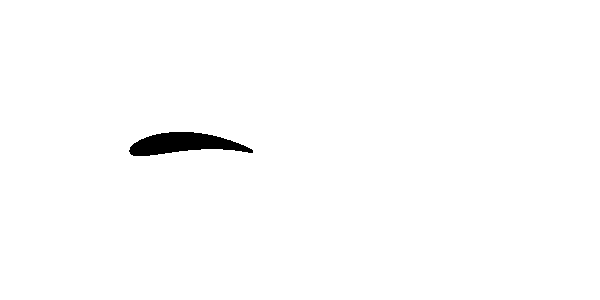

In [ ]:
#x = np.arange(-1, 1, 0.00125)
#y = np.arange(-0.5, 0.5, 0.00125)

center = (-0.5, 0)

alpha = 0*np.pi/180

b = 0.13
a = 0.15
offset = -0.0125 + 1j*0.025

beta = np.arcsin(np.imag(offset)/a)



zetaCylinder = a*np.exp(1j*np.arange(0.,np.pi*2.,0.0001))+offset
Zfoil = zetaCylinder + b**2/zetaCylinder
Zfoil = Zfoil * np.exp(-1j*alpha)

fig, ax = plt.subplots(figsize=(6, 3))
#ax.set_position([0, 0, 1, 1])
ax.fill(np.real(Zfoil) + center[0], np.imag(Zfoil) + center[1], color='k', antialiased=False)
ax.set_aspect(1)
# ax.set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xticks([])
ax.set_yticks([])

ax.set_xlim(-1, 1)
ax.set_ylim(-0.5, 0.5)

fig.savefig(f'2d-fluid-simulator/images/bc_mask/airfoil_a{a}_offset{np.real(offset)}{np.imag(offset)}alpha{alpha:1.2f}.png', dpi=300)
print(f'2d-fluid-simulator/images/bc_mask/airfoil_a{a}_offset{np.real(offset)}{np.imag(offset)}alpha{alpha:1.2f}.png')

print(f'alpha={alpha}, beta={beta}, lift/\\rho U^2 = {4*np.pi*a*np.sin(alpha+beta)}')


In [147]:
!cp 2d-fluid-simulator/images/bc_mask/airfoil_a0.15_offset-0.01250.025alpha0.00.png 2d-fluid-simulator/images/bc_mask/airfoil.png

## Q3.2: Run the simulation:

This simulation should ideally be run at higher resolution, thought it is possible your computer may not be up for it.  I also ran it for about 7000 s.  

`python main.py -bc 6 -re 400_000 -res 800 -dt 0.0002 -vc 0.0  --save 200 --cpu --savedir output_airfoil_00`

Create the airfoil for different attack angles by changing `alpha` in the code above. I did this for -15, -10, ... 15, 20 degrees.  Copy the airfoil shape and rerun the code above for about 7000 s, and be sure to change the name of the directory you are saving into (eg `output_airfoil_10` for 10 degrees of attack).  You should have 8 directories with simulation outputs in them.

## Q3.3 Plot the simulations

I plotted these all on one figure at `time=7000` - and I just plotted u.  Comment on the qualitative differences.

m15
m10
m5
00New
05
10
15
20


Text(0.5, 0, 'x [m]')

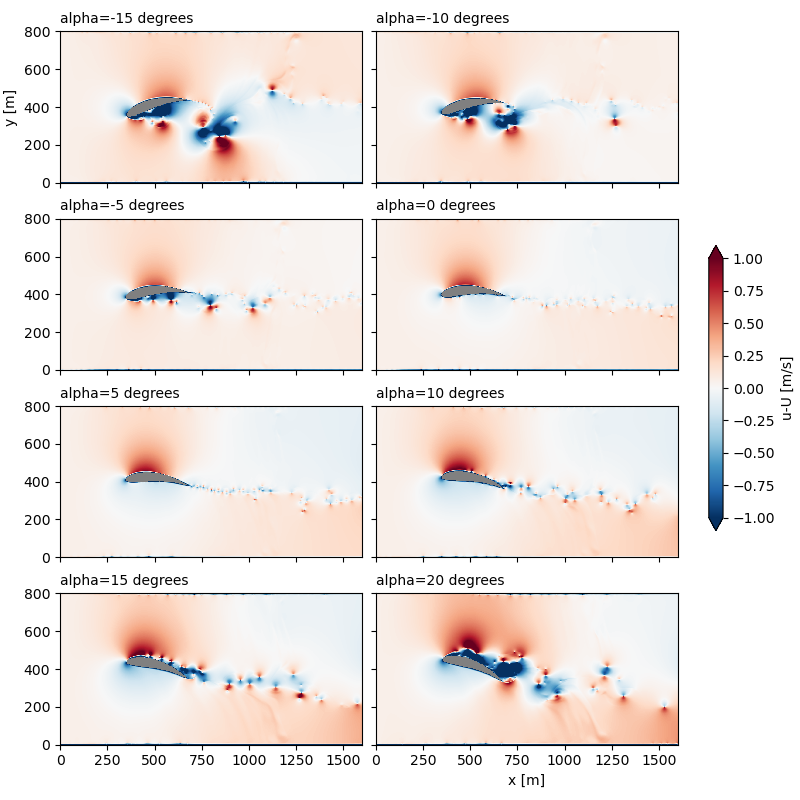

In [149]:
angle = np.array([-15, -10, -5, 0, 5, 10, 15, 20])
fig, axs = plt.subplots(4, 2, sharex=True, sharey=True, figsize=(8, 8), layout='compressed')

for nn, alpha in enumerate(angle):
    ax = axs.flat[nn]
    td = f'{alpha:02d}' if alpha >= 0 else f'm{abs(alpha):d}'
    if alpha == 0:
        td = f'{alpha:02d}New'
    print(td)
    with xr.open_mfdataset(f'2d-fluid-simulator/output_airfoil_{td}/output*.nc') as ds0:

        ds = ds0.sel(time=7000, method='nearest')
        pc = ax.pcolormesh( ds.u.T - 1, cmap='RdBu_r', clim=(-1, 1))
        ax.set_facecolor('0.5')
        ax.set_aspect(1)
        ax.set_title(f'alpha={alpha} degrees', loc='left', fontsize='medium')
axs[0, 0].set_ylabel('y [m]')
fig.colorbar(pc, ax=axs, shrink=0.4, extend='both', label='u-U [m/s]')
axs[-1, -1].set_xlabel('x [m]')


For alpha=0, the flow is clearly stronger over the top of the wing than under the wing, and this will lead to net lift. There is a trailing vortex in all the runs, though much weaker in the runs with smaller angles of attack.  For runs with high angles of attack, flow separation from the leading edge becomes strong, and this will likely lead to the wing stalling.

## Q3.4 Calculate the lift and circulation around the wing and plot versus angle of attack. 

For each run, calculate the lift on the wing, and the circulation around the wing.  

Note: for the lift, we want to integrate the pressure around the wing as it acts in the vertical. To do this you need to find the top and bottom of the wing in the matrix.  I did this with a for-loop initially.  Note that there are also some questionable pressure values right against the body, so I took the pressure value either one cell above or once cell below the wing for each value of x.  To figure this out, I suggest the code defined below.  Note that for the circulation, you need only choose a loop that is disjoint from the body, but given the lack of steadiness in the problem, it is a good idea to choose the loop a little ways from the wing.

Comment on agreement, or lack thereof with the expected lift, given $\alpha$ and $\sin \beta = \mathrm{imag(z_0)}/a$.  Also discuss how you think the drag changes as the attack angle changes (but don't calculate).



In [227]:
# get the lift and circulations:
def find_top_bottom(matrix):
    # Create a boolean mask where NaNs are True
    mask = np.isnan(matrix)

    # Get the top boundary by finding the first True in each column
    bottom = np.where(mask.any(axis=0), mask.argmax(axis=0), np.nan)

    # Get the bottom boundary by finding the last True in each column
    top = np.where(mask.any(axis=0), matrix.shape[0] - 1 - np.argmax(np.flip(mask, axis=0), axis=0), np.nan)
    top = top + 3
    bottom = bottom - 1
    return top, bottom


In [228]:

circ = 0.0 * angle
lift = 0.0 * angle
for nn, alpha in enumerate(angle):
    print(alpha)
    td = f'{alpha:02d}' if alpha >= 0 else f'm{abs(alpha):d}'
    with xr.open_mfdataset(f'2d-fluid-simulator/output_airfoil_{td}/output*.nc') as ds0:
        ds = ds0.sel(time=7000, method='nearest')
        dx = np.median(np.diff(ds.x))
        left = -ds.v[300, 250:550].sum() * dx
        right = +ds.v[750, 250:550].sum() * dx
        bottom = ds.u[300:750, 250].sum() * dx
        top = -ds.u[300:750, 550].sum() * dx
        circ[nn] = left+right+bottom+top

        top, bottom = find_top_bottom(ds.p[:, 1:-1].values.T)
        #top = top + 3
        #bottom = bottom - 1
        topi = top.copy()
        bottomi = bottom.copy()
        for i in range(0,len(ds.x)):
            if np.isnan(bottom[i]) or (bottom[i]<10):
                bottom[i] = 0.0
                top[i] = 0.0
            else:
                bottom[i] = ds.p[i, int(bottom[i])]
                top[i] = ds.p[i, int(top[i])]



        lift[nn] = np.nansum(bottom-top) * np.median(np.diff(ds.x))
        #print(f'alpha={alpha}, lift={left+right+bottom+top}, circulation={left+right+bottom+top}')


-15
-10
-5
0
5
10
15
20


[0. 0. 0. ... 0. 0. 0.]


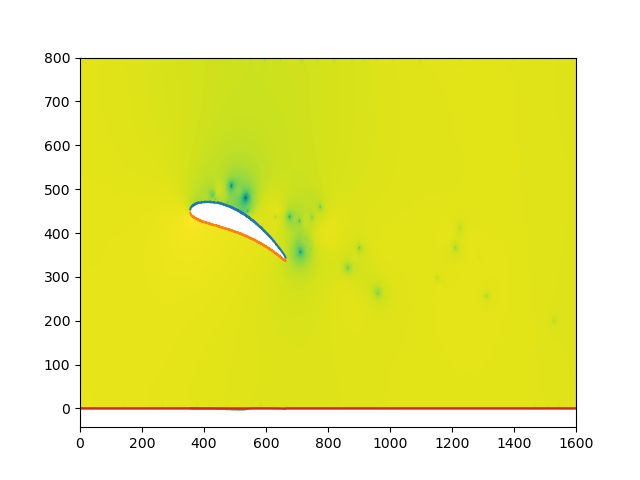

In [225]:
# plot an example pressure field
fig, ax = plt.subplots()
ax.plot(topi)
ax.plot(bottomi)
ax.pcolormesh(ds.p.T)
print(bottom)
ax.plot(top)
ax.plot(bottom)


Text(0, 0.5, '$Lift/\\rho\\ {[m^3/s^2]}$')

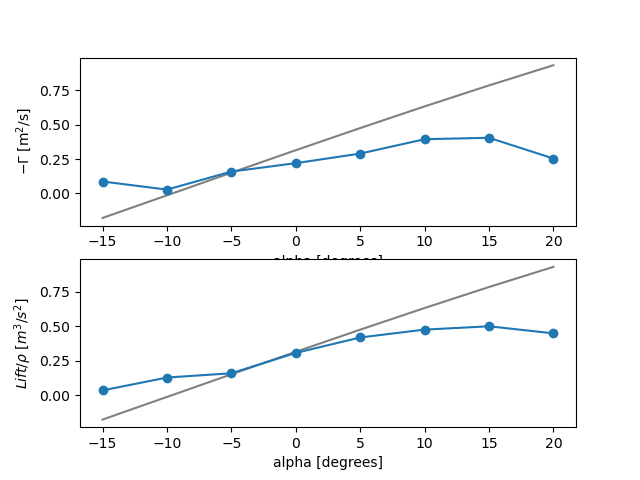

In [226]:
fig, axs = plt.subplots(2, 1)
ax = axs[0]
ax.plot(angle, theory, '-', color='0.5')
ax.plot(angle, -circ, 'o-')
theory = 4*np.pi*a*np.sin(angle*np.pi/180+beta)
ax.set_xlabel('alpha [degrees]')
ax.set_ylabel(r'$-\Gamma\ \mathrm{[m^2/s]}$')

ax = axs[1]
theory = 4*np.pi*a*np.sin(angle*np.pi/180+beta)
ax.plot(angle, theory, '-', color='0.5')
ax.plot(angle, lift, 'o-')
ax.set_xlabel('alpha [degrees]')
ax.set_ylabel(r'$Lift/\rho\ {[m^3/s^2]}$')

So we note that the simulated flow is relatively close to the theory for $\alpha \approx 0$, but deviates substantially for larger attack angles.  Interestingly, lift persists for negative attack angles, despite clear evidence fo flow separation.  I didn't ask you to calculate this, but drag clearly goes up for these flows.  